# **Consumer Loan Portfolio Analysis & Credit Risk Modelling**

Tools:** Python | Pandas | Matplotlib | Seaborn

This notebook explores the cleaned consumer loan portfolio to understand its composition, borrower characteristics, loan characteristics, and patterns associated with credit risk and default.

The analysis is structured around two main areas:

Consumer Credit Risk EDA: 
- Portfolio Profile: understanding the composition and characteristics of the loan portfolio, including loan  outcomes and origination patterns
- Borrower Risk: examining borrower characteristics and their relationship with credit risk
- Loan Risk: assessing how loan and credit characteristics vary across the portfolio and relate to observed risk

Default Risk EDA: conducting a focused analysis of the default outcome, including target variable definition, overall default patterns, and characteristics associated with higher observed default rates

The findings from the portfolio, borrower, loan, and default risk analyses will be used to develop key portfolio risk insights and provide an analytical basis for feature selection and subsequent predictive modelling.

## Data Loading & EDA Setup

This section loads the cleaned dataset and prepares the Python environment for exploratory analysis.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
loan_df = pd.read_csv("../data/loan_data_cleaned.csv")

In [3]:
loan_df.head()

,address_state,emp_length,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,loan_status,next_payment_date,purpose,sub_grade,term_months,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,GA,0,C,RENT,2021-02-11,2021-09-13,2021-04-13,Charged Off,2021-05-13,car,C4,60,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,CA,9,E,RENT,2021-01-01,2021-12-14,2021-01-15,Fully Paid,2021-02-15,car,E1,36,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,CA,4,C,RENT,2021-01-05,2021-12-12,2021-01-09,Charged Off,2021-02-09,car,C5,36,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,TX,0,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,Fully Paid,2021-04-12,car,B2,60,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,IL,10,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,Fully Paid,2021-02-15,car,A1,36,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [4]:
loan_df.shape

(38576, 20)

In [5]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   address_state          38576 non-null  object 
 1   emp_length             38576 non-null  int64  
 2   grade                  38576 non-null  object 
 3   home_ownership         38576 non-null  object 
 4   issue_date             38576 non-null  object 
 5   last_credit_pull_date  38576 non-null  object 
 6   last_payment_date      38576 non-null  object 
 7   loan_status            38576 non-null  object 
 8   next_payment_date      38576 non-null  object 
 9   purpose                38576 non-null  object 
 10  sub_grade              38576 non-null  object 
 11  term_months            38576 non-null  int64  
 12  verification_status    38576 non-null  object 
 13  annual_income          38576 non-null  float64
 14  dti                    38576 non-null  float64
 15  in

In [6]:
loan_df.isna().sum()

address_state            0
emp_length               0
grade                    0
home_ownership           0
issue_date               0
last_credit_pull_date    0
last_payment_date        0
loan_status              0
next_payment_date        0
purpose                  0
sub_grade                0
term_months              0
verification_status      0
annual_income            0
dti                      0
installment              0
int_rate                 0
loan_amount              0
total_acc                0
total_payment            0
dtype: int64

# **Consumer Credit Risk EDA**

This analysis examines the cleaned consumer loan portfolio from three complementary perspectives: **Portfolio Profile, Borrower Risk, and Loan Risk**.

**Portfolio Profile** provides a broad view of the portfolio by examining loan size, loan purpose, repayment terms, geographic distribution, loan outcomes, and origination activity. The aim is to understand where lending activity is concentrated and how the portfolio is structured before focusing on individual risk characteristics.

**Borrower Risk** examines borrower-level characteristics such as annual income, debt-to-income ratio (DTI), employment length, and home ownership. These variables provide context on the financial profiles represented in the portfolio and help identify areas of concentration and variation among borrowers.

**Loan Risk** focuses on loan-level characteristics, particularly interest rates, loan amounts, and credit grades. These variables describe how loans are priced, sized, and distributed across different credit-quality segments.

Together, these analyses establish the **composition, borrower profile, and lending characteristics** of the portfolio. The resulting observations provide the context needed for the subsequent **Default Risk EDA**, where default is treated as the main outcome and examined against selected borrower and loan characteristics.

## Portfolio Profile

This section examines the overall composition of the loan portfolio, focusing on loan amounts, purposes, repayment terms, geographic distribution, loan status, and origination timing. The objective is to understand how lending activity and loan outcomes are distributed across key portfolio characteristics before examining borrower and loan-level risk patterns.

### Loan Amount Distribution

The distribution of loan amounts is examined to understand the typical size of loans in the portfolio and identify whether lending exposure is concentrated around particular loan amounts or ranges.

In [7]:
loan_df["loan_amount"].describe()

count    38576.000000
mean     11296.066855
std       7460.746022
min        500.000000
25%       5500.000000
50%      10000.000000
75%      15000.000000
max      35000.000000
Name: loan_amount, dtype: float64

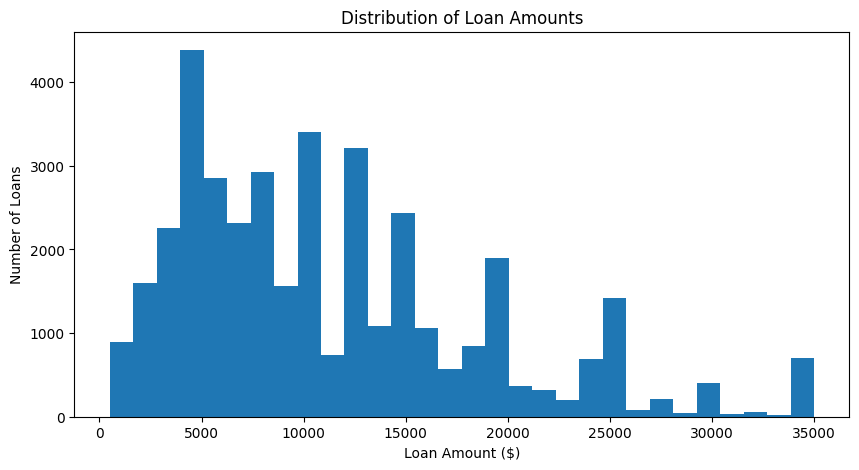

In [8]:
plt.figure(figsize=(10, 5))

plt.hist(loan_df["loan_amount"], bins=30)

plt.title("Distribution of Loan Amounts")
plt.xlabel("Loan Amount ($)")
plt.ylabel("Number of Loans")

plt.show()

**Insight:** Loan amounts are concentrated in the lower-to-mid range of the portfolio, with fewer loans at higher amounts. The distribution is right-skewed, indicating that a relatively small number of loans account for larger borrowing amounts. The presence of distinct peaks also suggests that borrowers tend to select from specific loan amount levels.

### Loan Purpose Distribution

This analysis examines the purposes for which borrowers obtained loans and assesses how concentrated the portfolio is across different loan purposes.

In [9]:
loan_df["purpose"].value_counts()

purpose
Debt consolidation    18214
credit card            4998
other                  3824
home improvement       2876
major purchase         2110
small business         1776
car                    1497
wedding                 928
medical                 667
moving                  559
house                   366
vacation                352
educational             315
renewable_energy         94
Name: count, dtype: int64

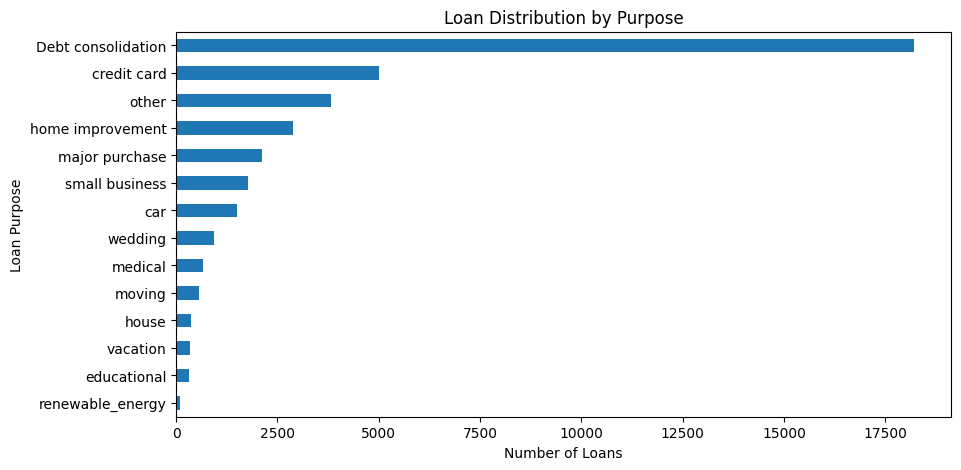

In [10]:
plt.figure(figsize=(10, 5))

loan_df["purpose"].value_counts().sort_values().plot(kind="barh")

plt.title("Loan Distribution by Purpose")
plt.xlabel("Number of Loans")
plt.ylabel("Loan Purpose")

plt.show()

**Insight:** The portfolio is highly concentrated in debt consolidation loans, which account for substantially more loans than any other purpose. Credit card and other purposes form the next largest categories, while the remaining purposes represent relatively small portions of the portfolio. This indicates that debt consolidation is a major component of the portfolio and should be examined further when assessing default patterns and portfolio risk.

### Loan Term Distribution

This analysis examines the repayment terms of loans in the portfolio to understand whether lending is concentrated in shorter or longer repayment periods.

In [11]:
loan_df["term_months"].value_counts().sort_index()

term_months
36    28237
60    10339
Name: count, dtype: int64

In [12]:
loan_df["term_months"].value_counts(normalize=True).sort_index() * 100

term_months
36    73.198362
60    26.801638
Name: proportion, dtype: float64

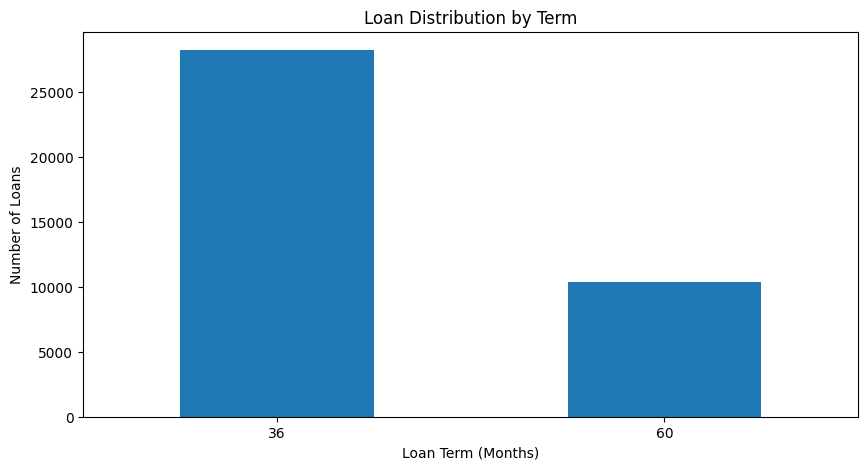

In [13]:
plt.figure(figsize= (10, 5))

loan_df["term_months"].value_counts().sort_index().plot(kind="bar")

plt.title("Loan Distribution by Term")
plt.xlabel("Loan Term (Months)")
plt.ylabel("Number of Loans")
plt.xticks(rotation=0)

plt.show()

**Insight:** The portfolio is predominantly composed of 36-month loans, which account for 75.34% of all loans, while 60-month loans represent 24.66%. This indicates a strong concentration toward shorter repayment terms. The relationship between loan term and default risk will be examined later to determine whether the longer repayment period is associated with higher observed default rates.

### Geographic Distribution

This analysis examines the geographic distribution of loans across borrower states to identify where the portfolio is most concentrated. The analysis focuses on loan volume rather than default risk, which will be examined later in the default analysis.

In [14]:
state_counts = loan_df["address_state"].value_counts()

state_counts.head(10)

address_state
CA    6894
NY    3701
FL    2773
TX    2664
NJ    1822
IL    1486
PA    1482
VA    1375
GA    1355
MA    1310
Name: count, dtype: int64

In [15]:
state_counts.head(10) / len(loan_df) * 100

address_state
CA    17.871215
NY     9.594048
FL     7.188407
TX     6.905848
NJ     4.723144
IL     3.852136
PA     3.841767
VA     3.564392
GA     3.512547
MA     3.395894
Name: count, dtype: float64

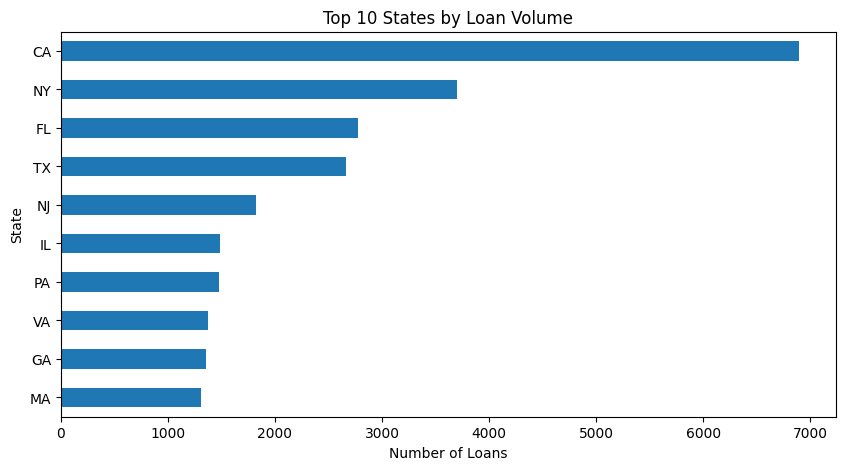

In [16]:
plt.figure(figsize=(10, 5))

state_counts.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 States by Loan Volume")
plt.xlabel("Number of Loans")
plt.ylabel("State")

plt.show()

**Insight:** The portfolio shows notable geographic concentration, with California accounting for the largest share of loans at 18.01%, followed by New York at 9.58%. Florida and Texas contribute 7.18% and 6.93%, respectively. The remaining states in the top ten each represent less than 5% of the portfolio individually. This concentration provides context for later analysis of whether default rates vary across geographic segments.

**Insight:** The portfolio is predominantly composed of Fully Paid loans, representing 83.3% of observations, while Charged Off loans account for 13.8% and Current loans represent 2.8%. The relatively small share of Current loans indicates that most observations have a resolved repayment outcome, while the presence of Charged Off loans provides a sufficient basis for analysing default patterns and identifying key risk drivers.

### Monthly Loan Origination Volume

Monthly loan origination volume shows the number of loans issued during each month of the observed period. Examining this measure helps assess changes in lending activity and identify periods of relatively higher or lower loan origination within the portfolio.

In [17]:
loan_df["issue_date"] = pd.to_datetime(loan_df["issue_date"])

In [18]:
monthly_loans = (
    loan_df.set_index("issue_date")
    .resample("ME")
    .size()
)

for date, count in monthly_loans.items():
    print(f"{date.strftime('%B %Y')}: {count:,} loans")

January 2021: 2,332 loans
February 2021: 2,279 loans
March 2021: 2,627 loans
April 2021: 2,755 loans
May 2021: 2,911 loans
June 2021: 3,184 loans
July 2021: 3,366 loans
August 2021: 3,441 loans
September 2021: 3,536 loans
October 2021: 3,796 loans
November 2021: 4,035 loans
December 2021: 4,314 loans


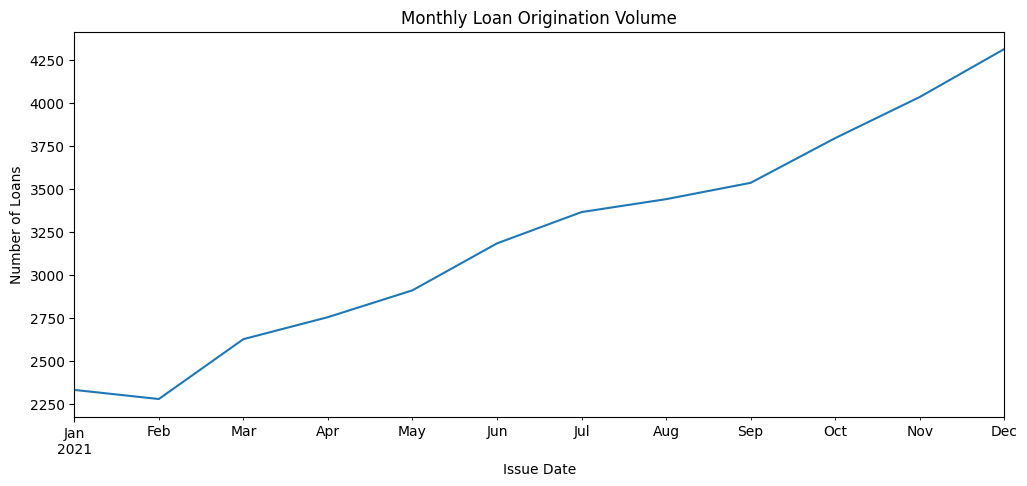

In [19]:
monthly_loans = (
    loan_df.set_index("issue_date")
    .resample("ME")
    .size()
)

monthly_loans.plot(figsize=(12, 5))
plt.title("Monthly Loan Origination Volume")
plt.xlabel("Issue Date")
plt.ylabel("Number of Loans")
plt.show()

**Insight:** Loan origination volume shows a clear upward trend across the observed period. After a slight decline from January to February, monthly originations increased steadily from March onward, reaching approximately 4,100 loans in December. The strongest growth occurred during the final quarter of the year, indicating that lending activity expanded considerably over the course of the year.

### Loan Status

This section examines the distribution of loan statuses across the portfolio and how loan status varies across key loan characteristics and origination periods. The analysis provides an overview of the portfolio's current and resolved loan outcomes, while identifying patterns in loan status across time, interest rates, and loan amounts. These observations provide context for defining the target variable and determining the appropriate dataset for subsequent default analysis and predictive modelling.

#### Distribution of loan status

The distribution of loan_status is examined to understand the composition of the loan portfolio across its different outcome categories. Both the number and percentage of loans in each status are assessed to provide a clear view of the relative size of each group before examining how loan status varies across other portfolio characteristics.

In [20]:
loan_status_counts = loan_df["loan_status"].value_counts()

loan_status_counts

loan_status
Fully Paid     32145
Charged Off     5333
Current         1098
Name: count, dtype: int64

In [21]:
loan_status_pct = (
    loan_df["loan_status"]
    .value_counts(normalize=True)
    .mul(100)
)

loan_status_pct

loan_status
Fully Paid     83.329013
Charged Off    13.824658
Current         2.846329
Name: proportion, dtype: float64

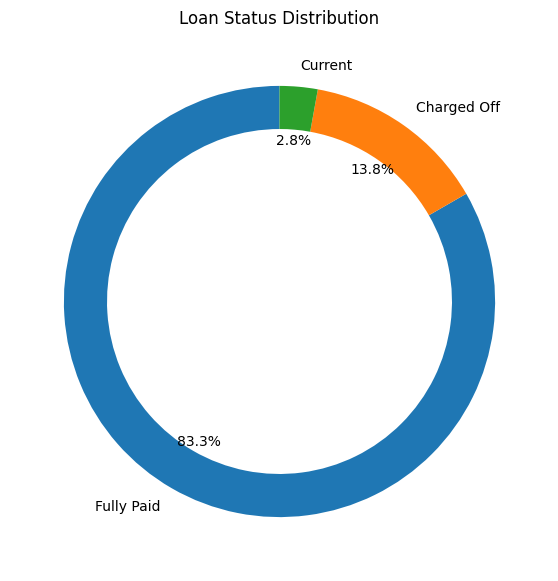

In [22]:
plt.figure(figsize=(7, 7))

plt.pie(
    loan_status_pct,
    labels=loan_status_pct.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.2),
    pctdistance=0.75
)

plt.title("Loan Status Distribution")
plt.show()

**Insight:** The portfolio is predominantly composed of Fully Paid loans, which account for 83.3% of all loans. Charged Off loans represent 13.8%, while Current loans make up the remaining 2.8%. This shows that most loans have reached a successful repayment outcome, while a smaller portion have resulted in default or remain unresolved.

#### Loan Status by Origination Period

Examining loan status across origination periods provides additional context on the composition of the portfolio over time. In particular, it helps determine whether `Current` loans are distributed similarly to resolved outcomes or concentrated within more recent origination periods.

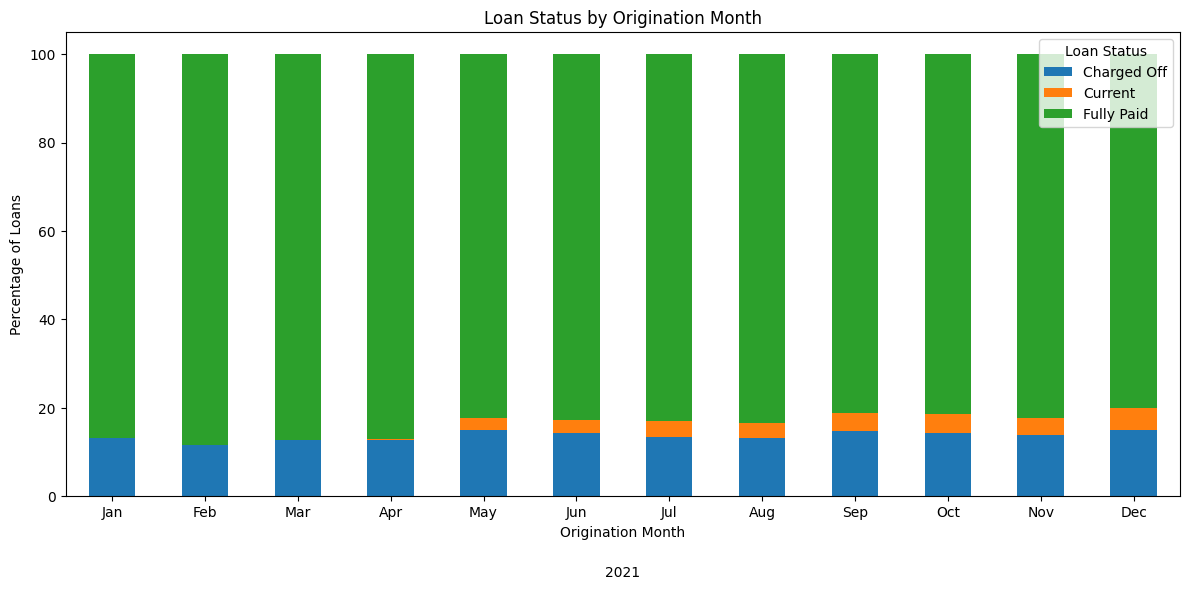

In [23]:
monthly_status = pd.crosstab(
    loan_df["issue_date"].dt.to_period("M"),
    loan_df["loan_status"],
    normalize="index"
) * 100

ax = monthly_status.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Loan Status by Origination Month")
plt.xlabel("Origination Month")
plt.ylabel("Percentage of Loans")


months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

ax.set_xticklabels(months, rotation=0)

plt.legend(title="Loan Status")


ax.text(
    0.5, -0.15, "2021",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=10
)

plt.tight_layout()
plt.show()

**Insight:** Loan status varies noticeably across origination periods. Current loans are concentrated in the later months, while earlier origination periods consist almost entirely of resolved outcomes (Fully Paid and Charged Off). This suggests that the Current status is associated with more recently originated loans that have not yet reached a final outcome. Therefore, Current loans should not be treated as either default or non-default when defining the modelling target.

#### Average Loan Characteristics by Loan Status

This analysis compares key loan characteristics across the different loan status categories. Mean loan amount and mean interest rate are calculated for each status to examine how these loan characteristics are distributed across the portfolio's repayment outcomes.

In [24]:
loan_status_summary = (
    loan_df.groupby("loan_status")[["loan_amount", "int_rate"]]
    .mean()
    .rename(columns={
        "loan_amount": "Mean Loan Amount",
        "int_rate": "Mean Interest Rate (%)"
    })
)



loan_status_summary["Mean Interest Rate (%)"] = (
    loan_status_summary["Mean Interest Rate (%)"] * 100
).round(2)

loan_status_summary["Mean Loan Amount"] = (
    loan_status_summary["Mean Loan Amount"].round(0)
)


loan_status_summary = loan_status_summary.reset_index()
loan_status_summary

,loan_status,Mean Loan Amount,Mean Interest Rate (%)
0,Charged Off,12288.0,13.88
1,Current,17183.0,15.10
2,Fully Paid,10930.0,11.64


**Insight:** Current loans have the highest average loan amount and interest rate, followed by Charged Off loans, while Fully Paid loans have the lowest averages for both characteristics. This indicates that loan size and interest rate differ across loan status categories, with ongoing and charged-off loans generally associated with larger and higher-rate loans.

#### Distribution of Loan Amounts Across Loan Statuses

This analysis uses boxplots to examine the distribution of loan amounts across the different loan status categories. It compares the median, spread, and potential outliers of loan amounts within each status group.

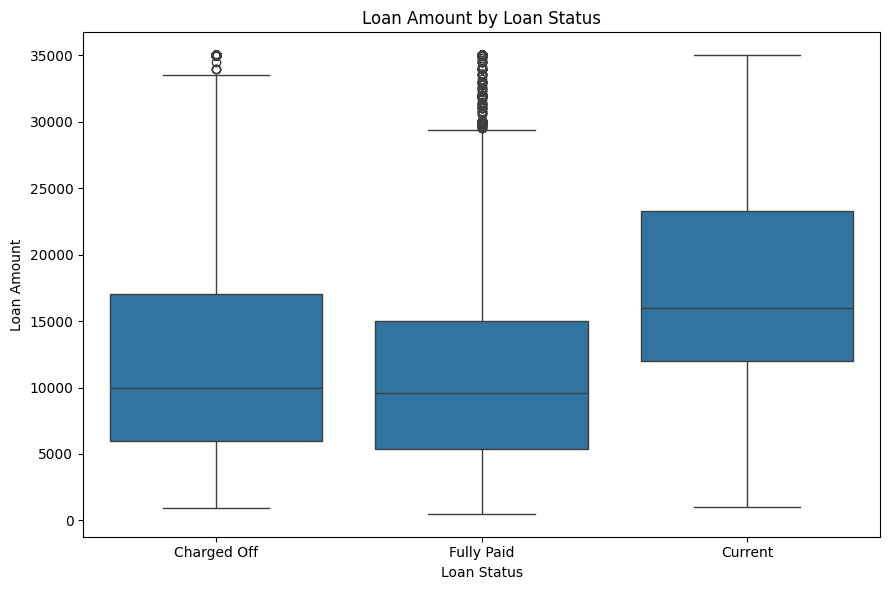

In [25]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=loan_df,
    x="loan_status",
    y="loan_amount"
)

plt.title("Loan Amount by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")
plt.tight_layout()
plt.show()

**Insight:** Current loans show noticeably higher and more dispersed loan amounts, indicating greater outstanding exposure among ongoing loans. However, the substantial overlap between Charged Off and Fully Paid loans suggests that loan amount alone does not clearly distinguish default outcomes, making it more useful for assessing exposure than standalone credit risk.

#### Loan Status and Outcome Definition

The loan status analysis shows that the portfolio contains both resolved and ongoing loan outcomes. Fully Paid and Charged Off represent resolved outcomes, while Current represents loans that remain active and therefore have not yet reached a final outcome. The analysis also shows that Current loans differ from the resolved groups in their distribution across origination periods and loan characteristics, particularly in terms of loan amount and interest rate. This distinction is important for subsequent default analysis, as an ongoing loan cannot yet provide definitive evidence of whether it will ultimately default or be fully repaid.

These observations will guide the definition of the default target later in the analysis, where resolved loan outcomes will provide the basis for distinguishing default from non-default.

## Borrower Risk

This section examines borrower-level characteristics that may influence credit risk. The analysis focuses on annual income, debt-to-income ratio (DTI), employment length, and home ownership to understand the financial profile of borrowers in the portfolio.

### Borrower Income

Annual income is examined to understand the financial capacity of borrowers and the typical income profile within the portfolio. Because income is highly right-skewed, both central tendency and percentile-based measures are considered to provide a more representative view of the typical borrower.

In [26]:
loan_df["annual_income"].describe()

count    3.857600e+04
mean     6.964454e+04
std      6.429368e+04
min      4.000000e+03
25%      4.150000e+04
50%      6.000000e+04
75%      8.320050e+04
max      6.000000e+06
Name: annual_income, dtype: float64

In [27]:
loan_df["annual_income"].quantile([0.01, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

0.01     15000.0
0.25     41500.0
0.50     60000.0
0.75     83200.5
0.90    117000.0
0.95    144000.0
0.99    235000.0
Name: annual_income, dtype: float64

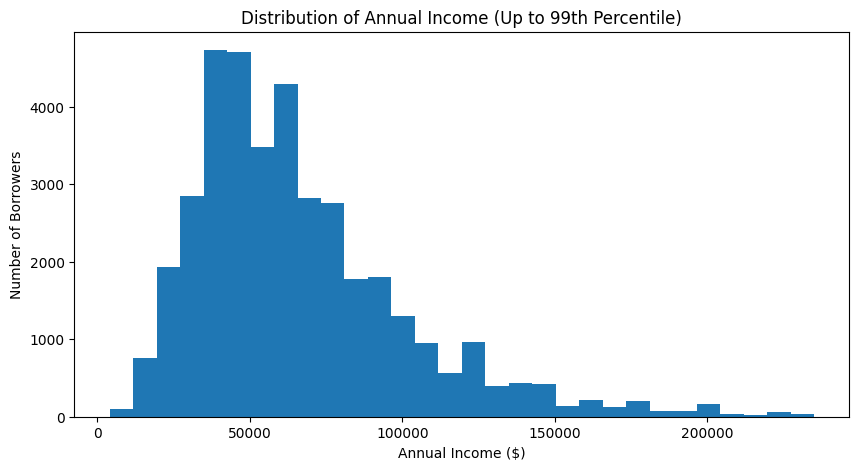

In [28]:
income_99 = loan_df["annual_income"].quantile(0.99)

plt.figure(figsize=(10, 5))

plt.hist(
    loan_df.loc[loan_df["annual_income"] <= income_99, "annual_income"],
    bins=30
)

plt.title("Distribution of Annual Income (Up to 99th Percentile)")
plt.xlabel("Annual Income ($)")
plt.ylabel("Number of Borrowers")

plt.show()

**Insight:** Borrower income is strongly right-skewed, with most borrowers concentrated in the lower-to-middle income range. The median annual income is $60,000, while the mean is higher at approximately $69,444, reflecting the influence of high-income observations. The 99th percentile is $235,000, compared with a maximum of $6 million, indicating that a small number of borrowers have exceptionally high reported incomes. These extreme observations are retained because they have not been established as data errors.

### Debt-to-Income Ratio

Debt-to-income ratio (DTI) is examined to assess the level of existing debt obligations relative to borrower income. Higher DTI values may indicate greater debt burden and potentially lower capacity to absorb additional loan obligations.

In [29]:
loan_df["dti"].describe()

count    38576.000000
mean         0.133274
std          0.066662
min          0.000000
25%          0.082100
50%          0.134200
75%          0.185900
max          0.299900
Name: dti, dtype: float64

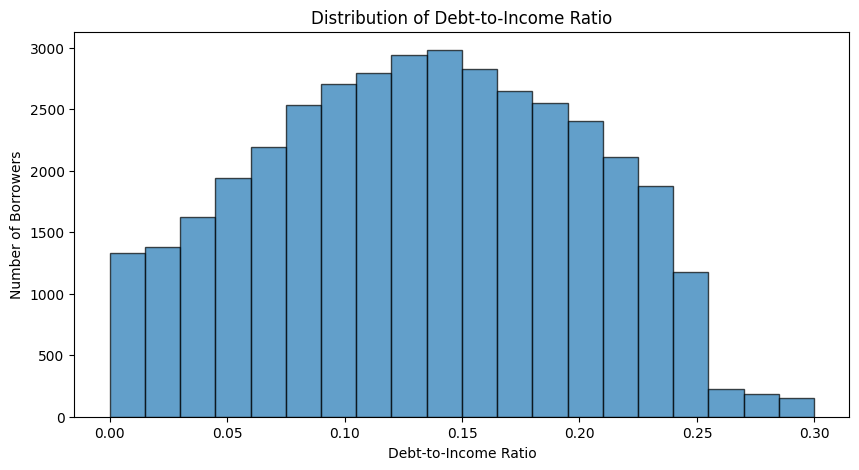

In [30]:
plt.figure(figsize=(10, 5))

plt.hist(
    loan_df["dti"],
    bins=20,
    edgecolor="black",
    alpha=0.7
)

plt.title("Distribution of Debt-to-Income Ratio")
plt.xlabel("Debt-to-Income Ratio")
plt.ylabel("Number of Borrowers")

plt.show()

**Insight:** The DTI distribution is approximately symmetric, with borrowers concentrated around the 0.10–0.17 range. The median DTI is 0.1339 and the mean is 0.1329, indicating very little difference between the two measures. The middle 50% of borrowers have DTI values between 0.0816 and 0.1855, while relatively few observations occur near the upper limit of 0.30. Overall, DTI appears to be reasonably well distributed across the portfolio without the extreme skewness observed in annual income.

### Employment Length

This analysis examines borrowers' employment length to understand the distribution of employment experience across the portfolio. Employment length is considered as a borrower characteristic that may provide context for financial stability and credit risk.

In [31]:
loan_df["emp_length"].value_counts().sort_index()

emp_length
0     4575
1     3229
2     4382
3     4088
4     3428
5     3273
6     2228
7     1772
8     1476
9     1255
10    8870
Name: count, dtype: int64

In [32]:
loan_df["emp_length"].value_counts(normalize=True).sort_index() * 100

emp_length
0     11.859706
1      8.370489
2     11.359394
3     10.597263
4      8.886354
5      8.484550
6      5.775612
7      4.593530
8      3.826213
9      3.253318
10    22.993571
Name: proportion, dtype: float64

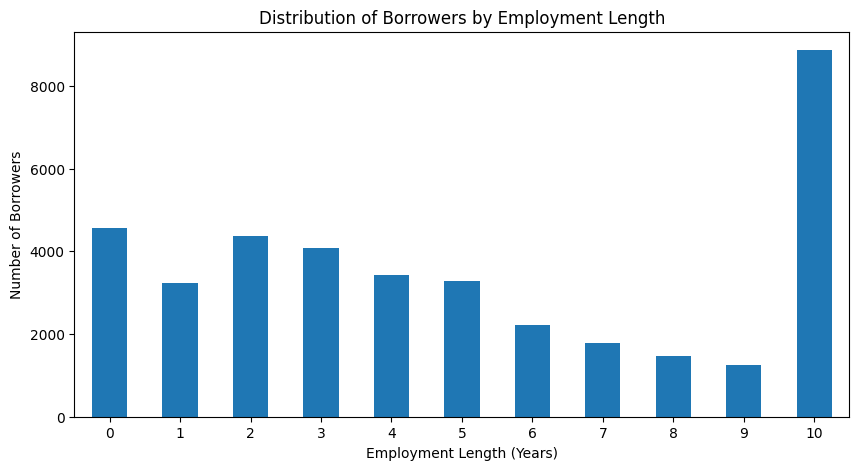

In [33]:
plt.figure(figsize=(10, 5))

loan_df["emp_length"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Borrowers by Employment Length")
plt.xlabel("Employment Length (Years)")
plt.ylabel("Number of Borrowers")
plt.xticks(rotation=0)

plt.show()

**Insight:** Employment length is distributed across a broad range of experience levels, with borrowers employed for 10+ years forming the largest group at 8,479 loans. Borrowers with less than one year of employment also represent a substantial group at 4,500 loans. The decline in observations across the middle employment categories is followed by a notable increase in the 10+ years category. Because the original 10+ years category is represented as 10, this value should be interpreted as 10 years or more rather than exactly 10 years.

### Home Ownership

This analysis examines borrowers' home ownership status to understand the composition of the portfolio across different housing situations. Home ownership provides additional context on borrowers' financial circumstances and will later be examined in relation to default risk.

In [34]:
loan_df["home_ownership"].value_counts()

home_ownership
RENT        18439
MORTGAGE    17198
OWN          2838
OTHER          98
NONE            3
Name: count, dtype: int64

In [35]:
loan_df["home_ownership"].value_counts(normalize=True) * 100

home_ownership
RENT        47.799150
MORTGAGE    44.582124
OWN          7.356906
OTHER        0.254044
NONE         0.007777
Name: proportion, dtype: float64

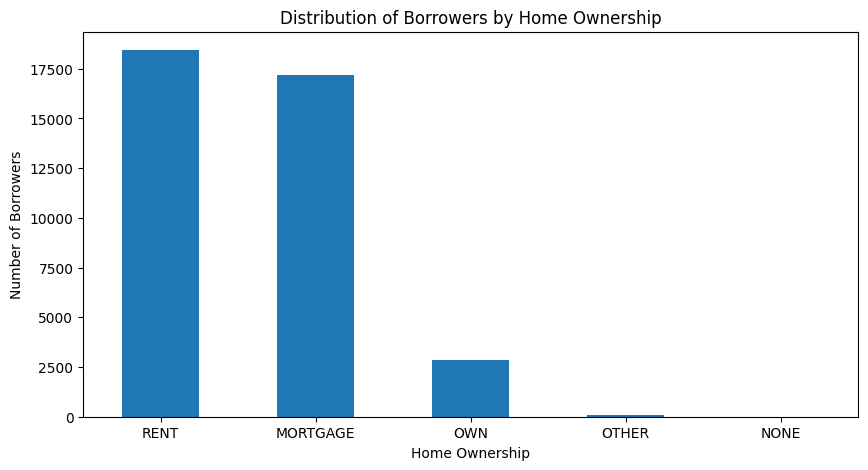

In [36]:
plt.figure(figsize=(10, 5))

loan_df["home_ownership"].value_counts().plot(kind="bar")

plt.title("Distribution of Borrowers by Home Ownership")
plt.xlabel("Home Ownership")
plt.ylabel("Number of Borrowers")
plt.xticks(rotation=0)

plt.show()

**Insight:** The portfolio is heavily concentrated among borrowers who either rent or have a mortgage. Renters account for 48.1% of borrowers, while mortgage holders account for 44.2%, together representing over 92% of the portfolio. Borrowers who own their homes outright account for 7.4%, while the `OTHER` and `NONE` categories represent less than 0.3% combined. The strong concentration in RENT and MORTGAGE should be considered when comparing default rates across home ownership categories.

## Loan Risk

This section examines the characteristics of the loans issued in the portfolio and how they may relate to credit risk. The analysis focuses on interest rates, loan amounts, and the credit grades assigned to each loan. These variables help describe how loans are priced, sized, and classified by risk level.

### Interest Rate

This analysis examines the distribution of loan interest rates across the portfolio. Interest rate is an important loan-level characteristic because it reflects differences in the pricing of credit across borrowers and may be associated with underlying credit risk.

In [37]:
loan_df["int_rate"].describe() 

count    38576.000000
mean         0.120488
std          0.037164
min          0.054200
25%          0.093200
50%          0.118600
75%          0.145900
max          0.245900
Name: int_rate, dtype: float64

In [38]:
loan_df["int_rate"].quantile([0.01, 0.25, 0.50, 0.75, 0.95, 0.99])

0.01    0.0542
0.25    0.0932
0.50    0.1186
0.75    0.1459
0.95    0.1862
0.99    0.2099
Name: int_rate, dtype: float64

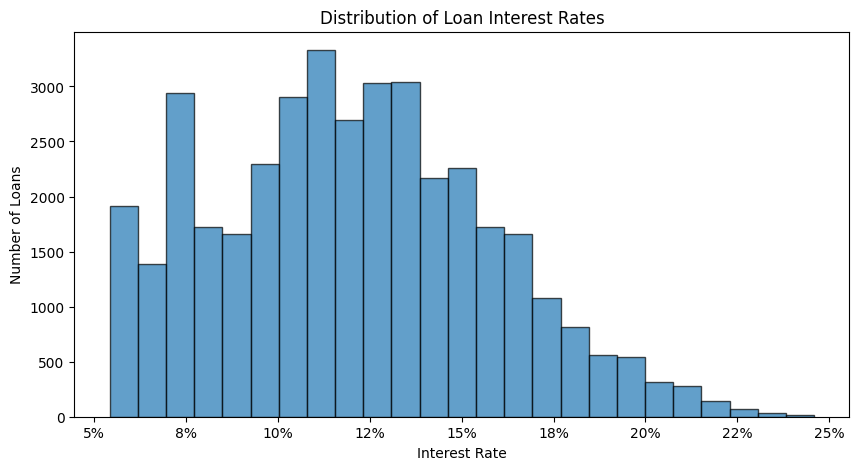

In [39]:
plt.figure(figsize=(10, 5))

plt.hist(loan_df["int_rate"], bins=25, edgecolor="black", alpha=0.7)

plt.title("Distribution of Loan Interest Rates")
plt.xlabel("Interest Rate")
plt.ylabel("Number of Loans")

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.0%}")
)

plt.show()

**Insight:** Loan interest rates are concentrated primarily between approximately 9% and 16%, with a median rate of 11.83% and a mean of 11.96%. The distribution shows a moderate right tail, with 5% of loans having interest rates above 18.39% and the maximum rate reaching 24.40%. The concentration of loans around the middle of the rate range suggests that most loans in the portfolio are priced within a relatively narrow band, while higher rates are less common.

### Loan Amount

This analysis examines the size of loans issued across the portfolio and the resulting exposure for the lender. In addition to assessing the overall distribution of loan amounts, loan size is compared across credit grades to determine whether loan exposure varies with the borrower's assigned risk classification.

In [40]:
loan_df["loan_amount"].describe()

count    38576.000000
mean     11296.066855
std       7460.746022
min        500.000000
25%       5500.000000
50%      10000.000000
75%      15000.000000
max      35000.000000
Name: loan_amount, dtype: float64

In [41]:
loan_df.groupby("grade")["loan_amount"].agg(["count", "mean", "median", "sum"])

,count,mean,median,sum
grade,,,,
A,9689,8695.657447,7500.0,84252225
B,11674,11196.160271,10000.0,130703975
C,7904,11064.834261,10000.0,87456450
D,5182,12335.160170,10362.5,63920800
E,2786,15852.512563,15000.0,44165100
F,1028,18395.379377,18000.0,18910450
G,313,20281.389776,20500.0,6348075


**Insight:** Loan size varies noticeably across credit grades. The average loan amount increases from approximately $8,688 for Grade A loans to $20,311 for Grade G loans. Median loan amounts show a similar pattern, particularly across the higher-risk grades E through G. This indicates that lower-grade loans in the portfolio tend to have larger loan exposures. However, this represents an observed association rather than a causal relationship.

### Credit Grade

Credit grade provides a broad classification of the risk level associated with each loan. This analysis examines how loans are distributed across grades A through G, providing an overview of the credit quality composition of the portfolio.

In [42]:
loan_df["grade"].value_counts().sort_index()

grade
A     9689
B    11674
C     7904
D     5182
E     2786
F     1028
G      313
Name: count, dtype: int64

In [43]:
loan_df["grade"].value_counts(normalize=True).sort_index() * 100

grade
A    25.116653
B    30.262339
C    20.489423
D    13.433223
E     7.222107
F     2.664869
G     0.811385
Name: proportion, dtype: float64

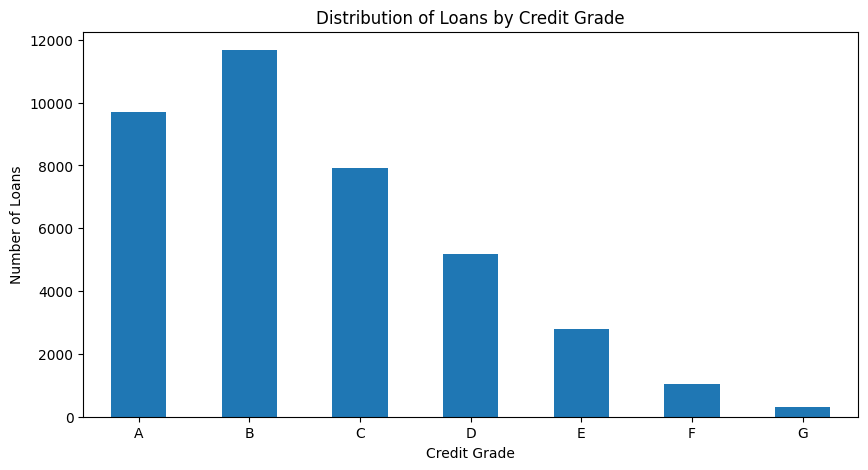

In [44]:
plt.figure(figsize=(10, 5))

loan_df["grade"].value_counts().sort_index().plot(
    kind="bar")

plt.title("Distribution of Loans by Credit Grade")
plt.xlabel("Credit Grade")
plt.ylabel("Number of Loans")
plt.xticks(rotation=0)

plt.show()

**Insight:** The portfolio is concentrated in the higher credit grades, with Grade B representing the largest share of loans at 30.28%, followed by Grade A at 25.76% and Grade C at 20.40%. Together, Grades A and B account for 56.04% of the portfolio, while Grades F and G represent only 3.34%. This indicates that most loans in the portfolio are concentrated in the higher-rated segments, with relatively limited representation of the lowest grades.

## Consumer Credit Risk Insights

This analysis examines the cleaned consumer loan portfolio from three complementary perspectives: **Portfolio Profile, Borrower Risk, and Loan Risk**.

**Portfolio Profile** provides a broad view of the portfolio by examining loan size, loan purpose, repayment terms, geographic distribution, loan outcomes, and origination activity. The aim is to understand where lending activity is concentrated and how the portfolio is structured before focusing on individual risk characteristics.

**Borrower Risk** examines borrower-level characteristics such as annual income, debt-to-income ratio (DTI), employment length, and home ownership. These variables provide context on the financial profiles represented in the portfolio and help identify areas of concentration and variation among borrowers.

**Loan Risk** focuses on loan-level characteristics, particularly interest rates, loan amounts, and credit grades. These variables describe how loans are priced, sized, and distributed across different credit-quality segments.

Together, these analyses establish the **composition, borrower profile, and lending characteristics** of the portfolio. The resulting observations provide the context needed for the subsequent **Default Risk EDA**, where default is treated as the main outcome and examined against selected borrower and loan characteristics.


# **Default Risk EDA**

Following the portfolio, borrower, and loan-level exploratory analysis, this section focuses specifically on the portfolio's default outcome. The objective is to examine the distribution and characteristics of observed default among loans with resolved outcomes and to identify patterns associated with higher default risk.

The analysis begins by defining a binary target variable based on the resolved loan outcomes identified in the preceding loan status analysis. It then examines the overall default rate and evaluates how default varies across key borrower, loan, credit, and portfolio characteristics.

This provides a focused assessment of the target variable before predictive modelling, helping to establish the underlying distribution of default, identify meaningful risk patterns, and provide an analytical basis for subsequent feature selection and model development.

## Target Variable Definition

The preceding loan status analysis identified three outcome categories within the portfolio: `Fully Paid`, `Charged Off`, and `Current`. For the subsequent default analysis and predictive modelling, a binary target variable is required to distinguish between loans that resulted in default and those that did not.

`Fully Paid` and `Charged Off` represent resolved loan outcomes and therefore provide a clear basis for defining the target. `Fully Paid` loans will be classified as non-default (`0`), while `Charged Off` loans will be classified as default (`1`). `Current` loans remain ongoing and do not yet have a resolved outcome, so their eventual credit outcome cannot be determined from the available data.

The default analysis will therefore focus on loans with resolved outcomes. A modelling dataset will be created from these loans, with the binary `default` variable defined from `loan_status`.

In [45]:
model_df = loan_df[loan_df["loan_status"] != "Current"].copy()

model_df["default"] = model_df["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1
})

In [46]:
model_df["default"].unique()

array([1, 0])

In [47]:
model_df["default"].value_counts()

default
0    32145
1     5333
Name: count, dtype: int64

In [48]:
model_df["default"].value_counts(normalize=True) * 100

default
0    85.770319
1    14.229681
Name: proportion, dtype: float64

In [49]:
model_df["default"].isna().sum()

np.int64(0)

### Transition to Default Analysis

The target variable definition converts the resolved loan outcomes into a binary measure of observed default, allowing the analysis to move from describing the composition of the portfolio to evaluating credit risk within loans with known outcomes. By restricting the modelling dataset to `Fully Paid` and `Charged Off` loans, the analysis avoids treating ongoing `Current` loans as if their eventual outcomes were already known.

This distinction is important because default analysis requires an observed outcome against which borrower and loan characteristics can be compared. The resulting `default` variable therefore provides a consistent basis for examining differences between non-default and defaulted loans across factors such as credit grade, interest rate, loan term, debt-to-income ratio, loan purpose, and borrower characteristics.

The default analysis will first establish the overall level of observed default within the resolved portfolio before examining how default rates vary across individual risk factors and portfolio segments. These comparisons will help identify patterns in the data, highlight characteristics associated with higher observed default rates, and provide an analytical basis for selecting relevant variables for the subsequent predictive modelling stage.

## Default Analysis

This section examines the observed default outcomes within the resolved loan portfolio and evaluates how default risk varies across key borrower, loan, credit, and portfolio characteristics. The analysis begins by establishing the overall default rate and then examines differences across credit grade, interest rate, debt-to-income ratio, loan term, loan purpose, home ownership, employment length, loan amount, and loan origination period. A focused comparison of default rates across sub-grades is also used to assess whether the more granular `sub_grade` classification provides sufficient additional value relative to the broader `grade` variable. These comparisons help identify patterns in observed default risk, assess the usefulness of individual risk factors, and provide a foundation for feature selection, risk segmentation, and predictive modelling.

### Overall Default Rate

This analysis establishes the overall default rate within the cleaned loan portfolio. The `default` variable identifies loans that were charged off (`1`) versus loans that were fully paid (`0`). Understanding the portfolio-level default rate provides a baseline for evaluating how default risk varies across borrower and loan characteristics.

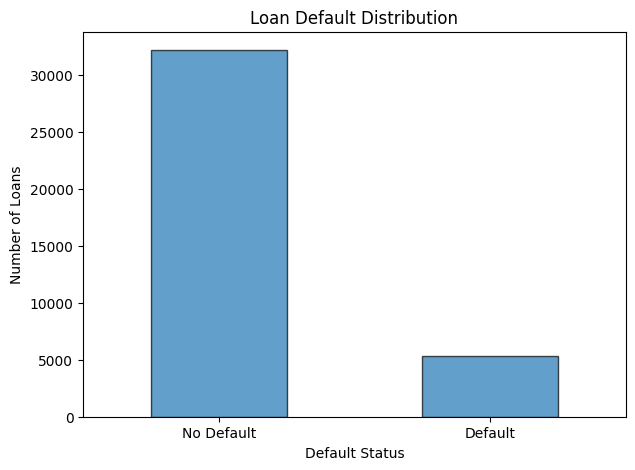

In [50]:
plt.figure(figsize=(7, 5))

model_df["default"].value_counts().sort_index().plot(
    kind="bar",
    edgecolor="black",
    alpha=0.7
)

plt.title("Loan Default Distribution")
plt.xlabel("Default Status")
plt.ylabel("Number of Loans")
plt.xticks([0, 1], ["No Default", "Default"], rotation=0)

plt.show()

In [51]:
default_rate = model_df["default"].mean() * 100

print(f"Overall default rate: {default_rate:.2f}%")

Overall default rate: 14.23%


**Insight:** The cleaned portfolio contains 32,145 loans that did not default and 5,333 loans that defaulted. This corresponds to an overall default rate of **14.23%**, meaning approximately 14 out of every 100 loans in the portfolio resulted in a charge-off. This rate provides the baseline for assessing how default risk varies across different borrower and loan characteristics in the following analyses. 

The target variable is moderately imbalanced, with non-defaulted loans substantially outnumbering defaults. This imbalance will be considered when evaluating predictive models.

### Default Rate by Credit Grade

Credit grade is designed to reflect the relative credit risk of a loan. This analysis compares the default rate across grades A through G to determine whether observed default risk follows the expected pattern across the portfolio.

In [52]:
default_by_grade = model_df.groupby("grade")["default"].mean() * 100

default_by_grade

grade
A     5.717837
B    11.835728
C    16.555512
D    21.586790
E    26.464956
F    32.497388
G    33.108108
Name: default, dtype: float64

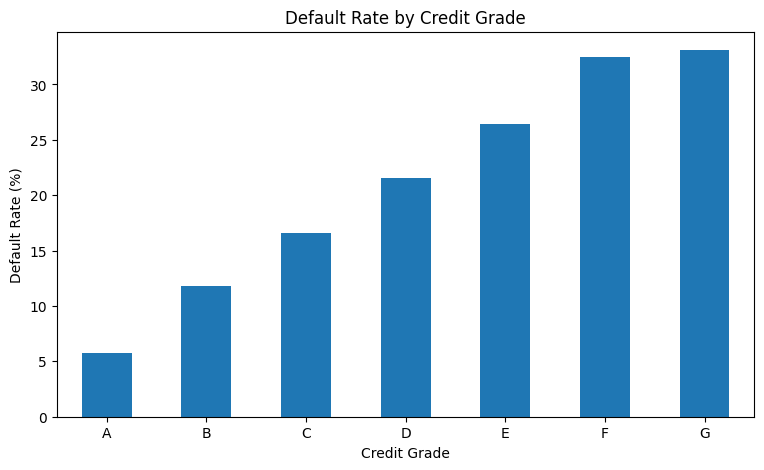

In [53]:
plt.figure(figsize=(9, 5))

default_by_grade.plot(
    kind="bar"
)

plt.title("Default Rate by Credit Grade")
plt.xlabel("Credit Grade")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

plt.show()

**Insight:** Default rates increase consistently as credit grade worsens, rising from 5.72% for Grade A loans to 33.11% for Grade G loans. The pattern remains strong across the major grades, with default rates increasing from 5.72% in Grade A to 32.50% in Grade F. Grade G shows a similar default rate of 33.11%, although it represents a much smaller segment of the portfolio with only 296 loans. Overall, credit grade shows one of the strongest and most consistent associations with observed default risk in the portfolio.

### Default Rate by Sub-Grade

The purpose is to examine whether the more granular `sub_grade` categories provide meaningful differentiation in observed default rates beyond the broader grade classification.

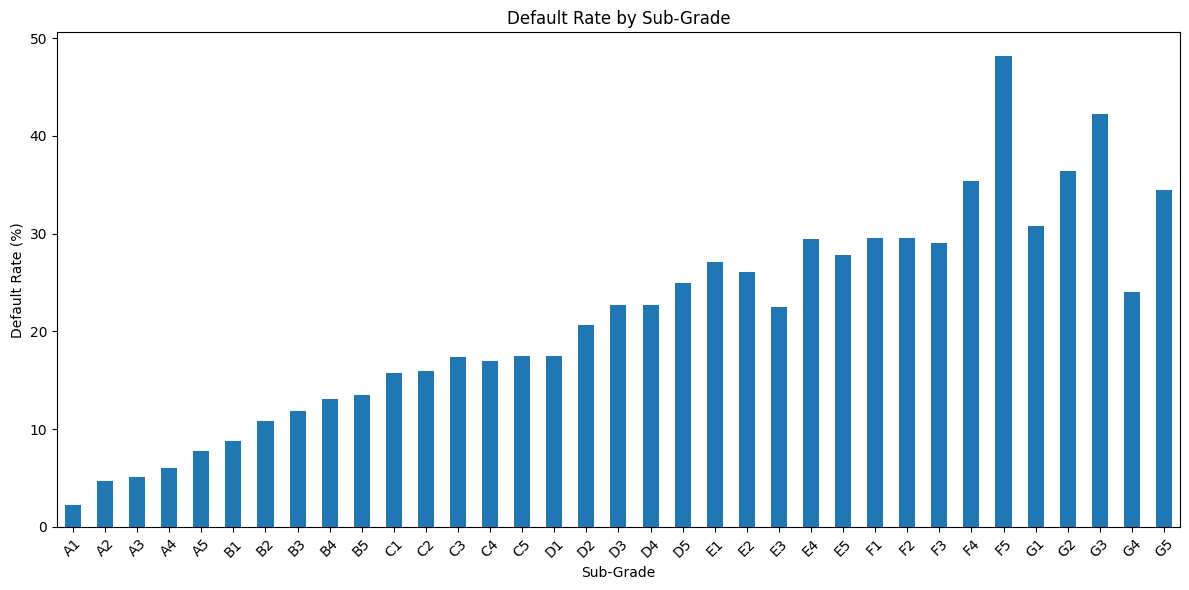

In [54]:
subgrade_default_rate = (
    model_df.groupby("sub_grade")["default"]
    .mean()
    .sort_index()
    * 100
)

plt.figure(figsize=(12, 6))
subgrade_default_rate.plot(kind="bar")

plt.title("Default Rate by Sub-Grade")
plt.xlabel("Sub-Grade")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:** Default rates vary across sub-grades, but the 35-category structure creates a highly granular segmentation with substantial differences in observation counts across categories. Given the sparsity of several sub-grades and the fact that sub_grade provides a more detailed version of the broader grade classification, its additional complexity may not provide enough incremental value to justify its inclusion in the model. sub_grade is therefore excluded from the final predictor set, while grade is retained as the more stable and interpretable credit-risk indicator.

### Default Rate by Interest Rate

Interest rate reflects the price charged for a loan and may also reflect the level of risk associated with the borrower. This analysis examines whether default rates vary across different interest-rate ranges, helping to identify whether higher-priced loans are associated with greater observed default risk.

In [55]:
interest_bins = [0.05, 0.10, 0.15, 0.20, 0.25]

interest_labels = [
    "5%–10%",
    "10%–15%",
    "15%–20%",
    "20%–25%"
]

model_df["int_rate_band"] = pd.cut(
    model_df["int_rate"],
    bins=interest_bins,
    labels=interest_labels,
    include_lowest=True
)

In [56]:
model_df["int_rate_band"].value_counts().sort_index()

int_rate_band
5%–10%     11827
10%–15%    17843
15%–20%     7050
20%–25%      758
Name: count, dtype: int64

In [57]:
default_by_rate = model_df.groupby(
    "int_rate_band",
    observed=True
)["default"].mean() * 100

default_by_rate

int_rate_band
5%–10%      6.392154
10%–15%    14.369781
15%–20%    24.453901
20%–25%    38.126649
Name: default, dtype: float64

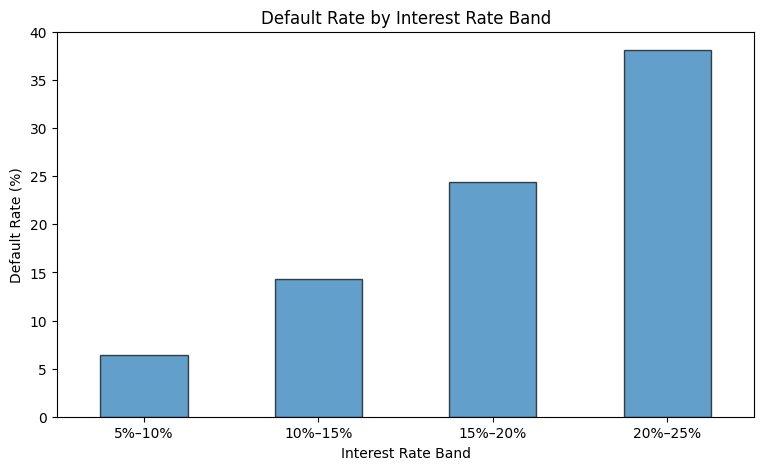

In [58]:
plt.figure(figsize=(9, 5))

default_by_rate.plot(
    kind="bar",
    edgecolor="black",
    alpha=0.7
)

plt.title("Default Rate by Interest Rate Band")
plt.xlabel("Interest Rate Band")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

plt.show()

**Insight:** Default rates increase substantially across the interest-rate bands. Loans with interest rates between 5%–10% have a default rate of 6.39%, compared with 14.37% for 10%–15% loans and 24.45% for 15%–20% loans. The highest-rate group, 20%–25%, has the highest default rate at 38.13%, although it contains only 758 loans and therefore represents a much smaller portion of the portfolio. Overall, the results show a strong positive relationship between interest rate and observed default risk, with higher-priced loans associated with considerably higher default rates. 

### Default Rate by Debt-to-Income Ratio

Debt-to-income ratio (DTI) measures a borrower's debt burden relative to their income. This analysis examines whether default rates vary across different DTI ranges, helping to determine whether borrowers with higher debt burdens exhibit greater observed default risk.

In [59]:
dti_bins = [0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

dti_labels = [
    "0%–5%",
    "5%–10%",
    "10%–15%",
    "15%–20%",
    "20%–25%",
    "25%–30%"
]

model_df["dti_band"] = pd.cut(
    model_df["dti"],
    bins=dti_bins,
    labels=dti_labels,
    include_lowest=True
)

In [60]:
model_df["dti_band"].value_counts().sort_index()

dti_band
0%–5%      4878
5%–10%     7636
10%–15%    9393
15%–20%    8585
20%–25%    6390
25%–30%     596
Name: count, dtype: int64

In [61]:
default_by_dti = model_df.groupby(
    "dti_band",
    observed=True
)["default"].mean() * 100

default_by_dti

dti_band
0%–5%      12.054121
5%–10%     12.414877
10%–15%    14.255296
15%–20%    15.422248
20%–25%    16.510172
25%–30%    13.255034
Name: default, dtype: float64

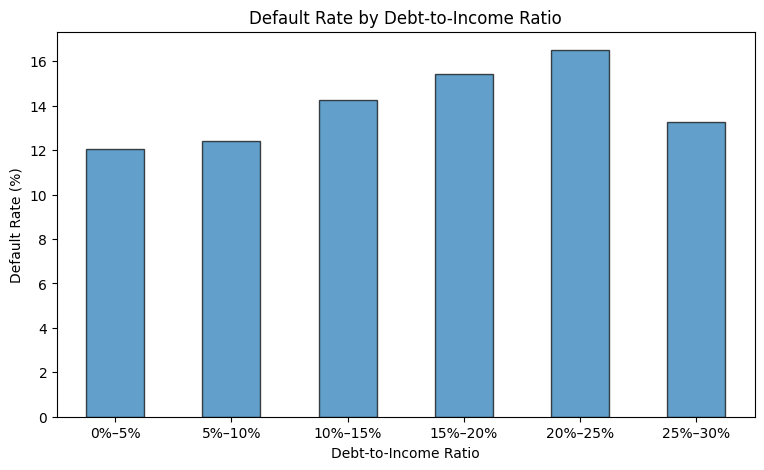

In [62]:
plt.figure(figsize=(9, 5))

default_by_dti.plot(
    kind="bar",
    edgecolor="black",
    alpha=0.7
)

plt.title("Default Rate by Debt-to-Income Ratio")
plt.xlabel("Debt-to-Income Ratio")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

plt.show()

**Insight:** Default rates generally increase as DTI rises, from 12.05% for borrowers with a DTI of 0%–5% to 16.51% for those in the 20%–25% range. The increase is relatively gradual compared with the stronger relationships observed for credit grade and interest rate. The 25%–30% group shows a lower default rate of 13.26%, but this group contains only 596 loans, making the estimate less representative of the overall portfolio. Overall, the results suggest a moderate positive relationship between DTI and observed default risk, although the relationship is not strictly increasing at the highest DTI range.

### Default Rate by Loan Term

Loan term represents the scheduled repayment period of a loan. This analysis compares default rates between 36-month and 60-month loans to determine whether repayment duration is associated with differences in observed default risk.

In [63]:
default_by_term = model_df.groupby("term_months")["default"].mean() * 100

default_by_term

term_months
36    10.705812
60    24.997295
Name: default, dtype: float64

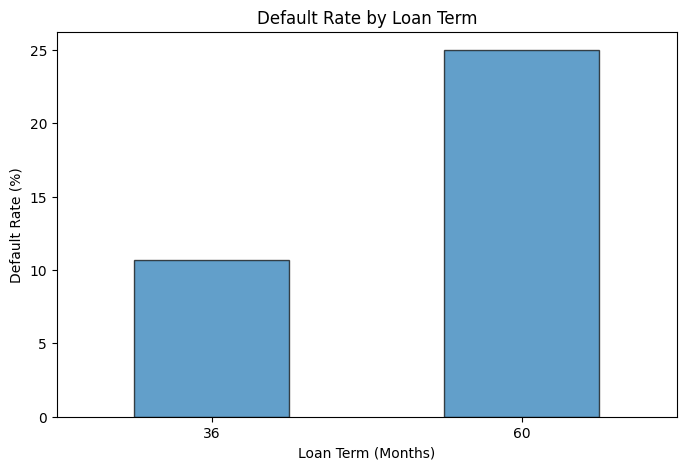

In [64]:
plt.figure(figsize=(8, 5))

default_by_term.plot(
    kind="bar",
    edgecolor="black",
    alpha=0.7
)

plt.title("Default Rate by Loan Term")
plt.xlabel("Loan Term (Months)")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

plt.show()

**Insight:** 60-month loans have a substantially higher default rate than 36-month loans, at 25.00% compared with 10.71%, respectively. This represents a difference of approximately **14.29 percentage points**, with the default rate for 60-month loans more than twice that of 36-month loans. Overall, the results indicate a strong association between longer loan terms and higher observed default risk in the portfolio.

### Default Risk by Borrower Employment Length

This analysis examines how observed default rates vary across different employment lengths. Comparing default rates by years of employment helps assess whether employment length is associated with differences in borrower credit risk within the resolved loan portfolio.

In [65]:
default_by_emp_length = (
    model_df.groupby("emp_length")["default"]
    .mean()
    .mul(100)
    .round(2)
)

default_by_emp_length

emp_length
0     14.02
1     14.09
2     13.09
3     13.68
4     13.62
5     14.10
6     14.12
7     15.32
8     13.97
9     12.67
10    15.59
Name: default, dtype: float64

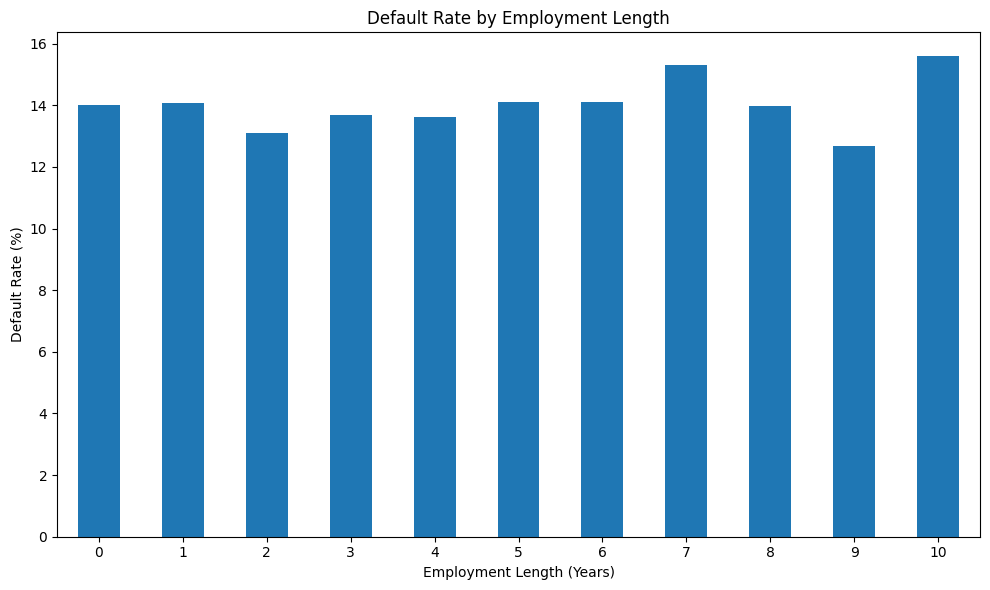

In [66]:
plt.figure(figsize=(10, 6))
default_by_emp_length.plot(kind="bar")

plt.title("Default Rate by Employment Length")
plt.xlabel("Employment Length (Years)")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Insight:** Default rates across employment lengths remain relatively close to the overall portfolio default rate of 14.23%, ranging from approximately 12.67% to 15.59%. There is also no clear or consistent relationship between employment length and observed default, as the rates fluctuate rather than increase or decrease systematically with years of employment. This suggests that emp_length has limited explanatory value as a standalone risk indicator in this portfolio. However, because its predictive value may differ when considered alongside other borrower and loan characteristics, it will be retained for the initial modelling stage and evaluated based on its incremental contribution to model performance.

### Monthly default rate

Monthly default rate measures the proportion of loans originated in each month that ultimately resulted in a default. Examining this measure helps assess whether observed credit risk varied across different loan origination periods.

In [67]:
monthly_default_rate = (
    model_df.set_index("issue_date")["default"]
    .resample("ME")
    .mean()
    .mul(100)
)

for date, rate in monthly_default_rate.items():
    print(f"{date.strftime('%B %Y')}: {rate:.2f}%")

January 2021: 13.25%
February 2021: 11.58%
March 2021: 12.68%
April 2021: 12.79%
May 2021: 15.50%
June 2021: 14.67%
July 2021: 13.98%
August 2021: 13.62%
September 2021: 15.38%
October 2021: 15.04%
November 2021: 14.45%
December 2021: 15.83%


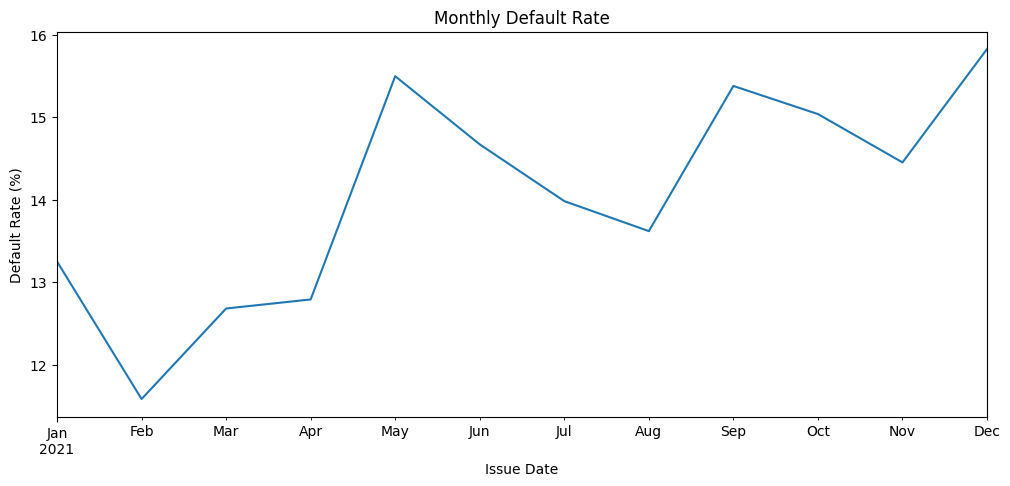

In [68]:
monthly_default_rate.plot(figsize=(12, 5))
plt.title("Monthly Default Rate")
plt.xlabel("Issue Date")
plt.ylabel("Default Rate (%)")
plt.show()

**Insight:** Observed default rates fluctuate across the year rather than following a consistent upward or downward trend. The monthly default rate ranges from approximately **11.6% in February to 15.8% in December**, with notable increases in May and September. Although December records the highest observed default rate, the variation across months is relatively moderate compared with the stronger differences observed across credit grades, interest-rate bands, and loan terms. Overall, the results suggest that the timing of loan origination is associated with some variation in observed default rates, but does not show a clear directional trend within the available period.

> **Note:** Default-rate analysis is based on loans with resolved outcomes, excluding loans with a `Current` status. This ensures that default rates are calculated only for loans whose repayment outcome is recorded as either `Fully Paid` or `Charged Off`.

## Risk Segmentation

This section examines how default risk varies across different borrower and loan segments. Rather than focusing only on individual risk characteristics, the analysis compares groups of borrowers and loans to identify segments with relatively higher or lower observed default rates.

The objective is to identify meaningful differences in portfolio risk across loan purposes and borrower profiles, providing additional context for the overall risk patterns identified in the default analysis.

### Default Rate by Loan Purpose

Loan purpose describes the intended use of each loan. This analysis compares default rates across different loan purposes to determine whether the reason for borrowing is associated with differences in observed default risk.

In [69]:
default_by_purpose = model_df.groupby("purpose")["default"].mean() * 100

default_by_purpose.sort_values(ascending=False)

purpose
small business        26.717557
renewable_energy      18.279570
house                 16.193182
educational           15.873016
other                 15.847732
medical               15.267176
moving                15.217391
Debt consolidation    15.022383
vacation              14.367816
home improvement      11.754134
car                   10.704420
credit card           10.373698
major purchase         9.927711
wedding                9.481808
Name: default, dtype: float64

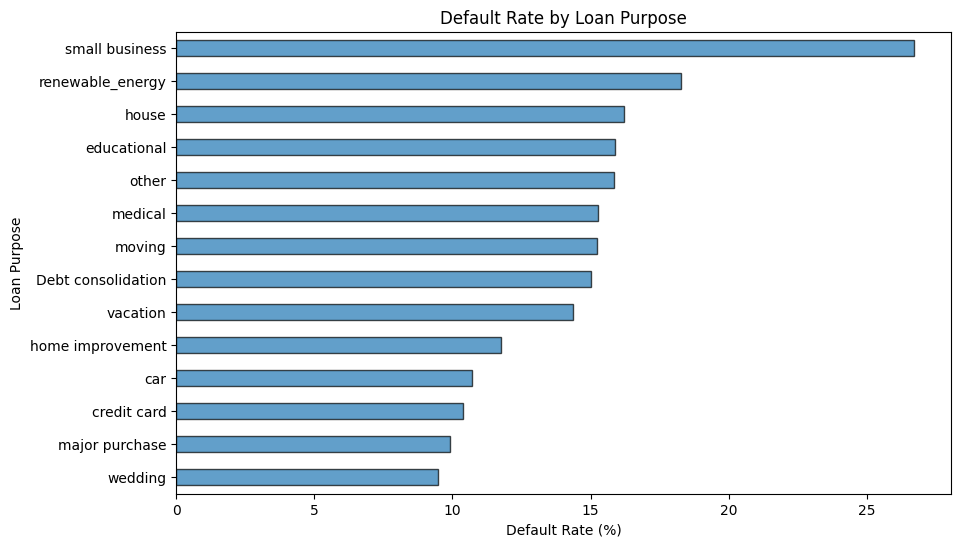

In [70]:
plt.figure(figsize=(10, 6))

default_by_purpose.sort_values().plot(
    kind="barh",
    edgecolor="black",
    alpha=0.7
)

plt.title("Default Rate by Loan Purpose")
plt.xlabel("Default Rate (%)")
plt.ylabel("Loan Purpose")

plt.show()

**Insight:** Default rates vary considerably across loan purposes. Small business loans have the highest observed default rate at 26.72%, followed by renewable energy loans at 18.28%. In contrast, wedding loans (9.48%), major purchase loans (9.93%), and credit card loans (10.37%) have the lowest observed default rates. Debt consolidation, despite being the largest loan-purpose segment in the portfolio, has a default rate of 15.02%, which is close to the overall portfolio default rate of 14.23%.

The results suggest that loan purpose may be associated with differences in observed default risk, with small business loans standing out as a higher-risk segment. However, categories with relatively few loans should be interpreted cautiously, as their default rates may be less stable and representative than those of larger segments.

### Default Rate by Home Ownership

Home ownership provides additional context about the borrower's financial and residential profile. This analysis compares default rates across different home ownership categories to determine whether observed default risk varies between borrowers who rent, have a mortgage, or own their homes.

In [71]:
default_by_home = model_df.groupby("home_ownership")["default"].mean() * 100

default_by_home.sort_values(ascending=False)

home_ownership
OTHER       18.367347
RENT        14.903766
OWN         14.347669
MORTGAGE    13.455160
NONE         0.000000
Name: default, dtype: float64

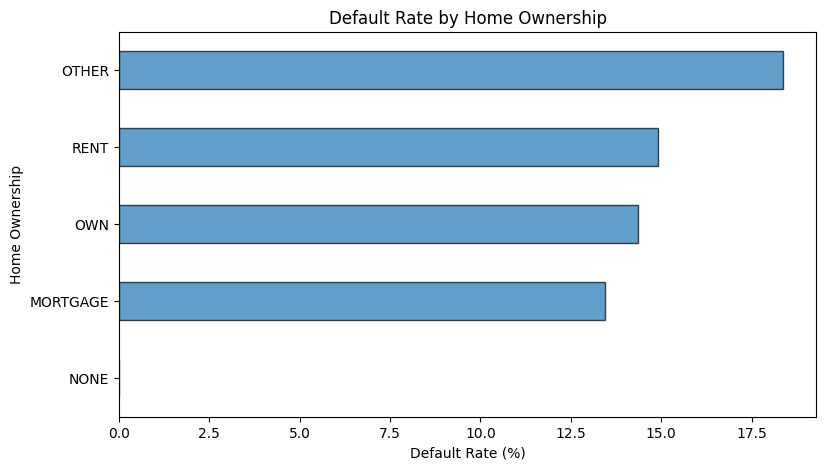

In [72]:
plt.figure(figsize=(9, 5))

default_by_home.sort_values().plot(
    kind="barh",
    edgecolor="black",
    alpha=0.7
)

plt.title("Default Rate by Home Ownership")
plt.xlabel("Default Rate (%)")
plt.ylabel("Home Ownership")

plt.show()

**Insight:** Default rates vary across home ownership categories, with borrowers classified as `OTHER` showing the highest observed default rate at 18.37%, followed by renters at 14.90% and homeowners at 14.35%. Borrowers with a mortgage have a slightly lower default rate of 13.46%. The `NONE` category records no defaults, but this category contains only 3 loans and is therefore not meaningful for risk comparison. Overall, the differences between the major home ownership groups are relatively modest, suggesting that home ownership has a weaker association with default risk than factors such as credit grade, interest rate, and loan term.

## Key Risk Insights

The EDA reveals several important patterns in the consumer loan portfolio and its default behavior. The strongest differences in observed default risk are associated with credit grade, interest rate, and loan term, while DTI and home ownership show weaker and less consistent relationships. Portfolio concentration is also important when interpreting these results, as some higher-risk segments contain relatively few loans.

### - Overall Portfolio Default Risk

The cleaned portfolio has an overall default rate of **14.23%**, with 5,333 of 37,478 loans resulting in a charge-off. This provides the baseline against which individual borrower and loan segments are evaluated.

### - Credit Grade Is a Strong Indicator of Default Risk

Default rates increase consistently as credit grade worsens, rising from **5.72% for Grade A** to **33.11% for Grade G**. This is one of the clearest patterns in the analysis, indicating that credit grade strongly differentiates observed default risk across the portfolio.

### - Higher Interest Rates Are Associated with Higher Default Rates

Default rates increase substantially across interest-rate bands, from **6.39% for loans between 5%–10%** to **38.13% for loans between 20%–25%**. This suggests a strong positive association between loan pricing and observed default risk, although the relationship should not be interpreted as causal.

### - Longer Loan Terms Show Higher Default Risk

60-month loans have a default rate of **25.00%**, compared with **10.71% for 36-month loans**. The difference of approximately **14.29 percentage points** indicates a strong association between longer repayment terms and observed default risk.

### - DTI Shows a Moderate but Less Consistent Relationship

Default rates generally increase with DTI, rising from **12.05% for the 0%–5% range** to **16.51% for the 20%–25% range**. However, the relationship is weaker than those observed for credit grade, interest rate, and loan term, and the highest DTI band does not continue the increasing pattern.

### - Risk Varies Across Loan Purposes, but Segment Size Matters

Small business loans have the highest observed default rate at **26.72%**, while wedding loans have the lowest at **9.48%**. However, smaller loan-purpose categories should be interpreted cautiously because their default rates may be less stable. Debt consolidation is particularly important because it represents the largest loan-purpose segment and has a **15.02% default rate**, close to the portfolio average.

### - Home Ownership Shows Relatively Weak Differences in Default Risk

The major home ownership groups show relatively modest differences in default rates, ranging from **13.46% for mortgage holders** to **14.90% for renters**. The `OTHER` category has a higher rate of 18.37%, but its small size limits its usefulness for comparison. Overall, home ownership appears to provide less differentiation in observed default risk than credit grade, interest rate, or loan term.

## Overall Risk Takeaway

The strongest risk differentiation in the portfolio comes from **credit grade, interest rate, and loan term**. DTI and loan purpose provide additional risk context, while home ownership shows comparatively limited differentiation. These findings provide a basis for identifying variables that should be considered in the subsequent machine learning stage.

# **Conclusion**

The exploratory analysis provides a clear picture of the consumer loan portfolio and the factors that are most relevant to its credit risk. The portfolio is concentrated in a relatively small number of segments, particularly **36-month loans, Grades A–C, and debt consolidation**, while renters and mortgage holders together account for more than 92% of borrowers. Loan originations also increased considerably over the observed period, giving useful context for how the portfolio developed over time.

More importantly, the default analysis shows that **not all portfolio characteristics provide the same level of risk differentiation**. Credit grade, interest rate, and loan term show the clearest differences in observed default rates, while DTI provides a weaker and less consistent relationship. Employment length and home ownership provide additional borrower context, but show relatively limited standalone differentiation in this portfolio. The analysis also shows why portfolio size matters when interpreting risk: some categories with high observed default rates contain relatively few loans and may therefore produce less stable estimates.

The analysis also helped establish a more appropriate modelling framework. `Current` loans were excluded because they do not yet have a resolved outcome, leaving **37,478 resolved loans** for the binary default analysis. Within this group, **5,333 loans were charged off**, giving an overall observed default rate of **14.23%**. The resulting target is moderately imbalanced, which will be considered during model evaluation.

> **An important limitation is that these findings describe patterns within this particular dataset and should not be interpreted as universal relationships or evidence of causation.** Some categories are relatively small, `sub_grade` is highly granular, and extreme income observations remain in the data because they were not established as errors. The analysis is therefore most useful for identifying patterns within the portfolio and guiding the predictive modelling stage rather than making broader claims about borrower behaviour.

Overall, the EDA provides a practical foundation for the machine learning stage by identifying the variables that show meaningful risk patterns, highlighting weaker standalone predictors, and separating information that would introduce **data leakage** from information available at the time of loan origination. The final modelling dataset therefore focuses on **origination-time borrower, loan, credit, geographic, and timing characteristics**, with the binary `default` outcome as the prediction target.

---


> **Final takeaway:** the EDA moves the project from simply describing the loan portfolio to understanding **where observed credit risk is concentrated and which characteristics are most useful to investigate through predictive modelling.**


# **Model Dataset Preparation**

This section prepares the dataset for the predictive modelling stage by reviewing the available variables, identifying the features to be retained, and separating the predictors from the target variable.

The objective is to create a **model-ready dataset** containing only the variables selected for prediction while removing columns that are not required for the modelling stage.


In [73]:
model_df.columns.tolist()

['address_state',
 'emp_length',
 'grade',
 'home_ownership',
 'issue_date',
 'last_credit_pull_date',
 'last_payment_date',
 'loan_status',
 'next_payment_date',
 'purpose',
 'sub_grade',
 'term_months',
 'verification_status',
 'annual_income',
 'dti',
 'installment',
 'int_rate',
 'loan_amount',
 'total_acc',
 'total_payment',
 'default',
 'int_rate_band',
 'dti_band']

In [74]:
model_features = [
    "address_state",
    "emp_length",
    "grade",
    "home_ownership",
    "issue_date",
    "purpose",
    "term_months",
    "verification_status",
    "annual_income",
    "dti",
    "installment",
    "int_rate",
    "loan_amount",
    "total_acc"
]


In [75]:
model_df = model_df[model_features + ["default"]].copy()

In [76]:
model_df.shape

(37478, 15)

In [77]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37478 entries, 0 to 38557
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   address_state        37478 non-null  object        
 1   emp_length           37478 non-null  int64         
 2   grade                37478 non-null  object        
 3   home_ownership       37478 non-null  object        
 4   issue_date           37478 non-null  datetime64[ns]
 5   purpose              37478 non-null  object        
 6   term_months          37478 non-null  int64         
 7   verification_status  37478 non-null  object        
 8   annual_income        37478 non-null  float64       
 9   dti                  37478 non-null  float64       
 10  installment          37478 non-null  float64       
 11  int_rate             37478 non-null  float64       
 12  loan_amount          37478 non-null  int64         
 13  total_acc            37478 non-null 

In [78]:
model_df.head(3)

,address_state,emp_length,grade,home_ownership,issue_date,purpose,term_months,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,default
0,GA,0,C,RENT,2021-02-11,car,60,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1
1,CA,9,E,RENT,2021-01-01,car,36,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,0
2,CA,4,C,RENT,2021-01-05,car,36,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,1


## Defining Features and Target

The predictor variables are assigned to **X**, while the `default` variable is assigned to **y**, representing the target outcome the model will learn to predict.

In [79]:
X = model_df.drop(columns="default")
y = model_df["default"]

## Rationale for Feature Selection

The modelling dataset contains **14 predictor variables** selected based on their relevance to borrower characteristics, loan characteristics, credit risk, geography, and loan origination timing. The selection is informed by the preceding exploratory and default risk analyses while considering data availability at the point of loan origination and the risk of data leakage.

- **Borrower characteristics:** `emp_length`, `annual_income`, `dti`, `home_ownership`, `verification_status`, and `total_acc` provide information about the borrower's financial position, debt burden, and credit background.

- **Loan characteristics:** `loan_amount`, `term_months`, `installment`, `int_rate`, and `purpose` capture key characteristics of the loan and its repayment structure.

- **Credit risk indicators:** `grade` provides measures of the borrower's assessed credit risk at origination.

- **Geographic information:** `address_state` captures potential differences in borrower and portfolio characteristics across locations.

- **Time information:** `issue_date` is retained because the loan's origination date is known at the time of lending and can capture temporal differences in portfolio composition and observed default risk.

Variables such as `loan_status`, `total_payment`, `last_payment_date`, `next_payment_date`, and `last_credit_pull_date` are excluded because they reflect loan performance or credit activity occurring after origination and therefore would not be reliably available when making an origination-time prediction. Including these variables could introduce **data leakage**. The EDA-derived variables `int_rate_band` and `dti_band` are also excluded because their underlying continuous variables, `int_rate` and `dti`, retain more detailed information for modelling. **`sub_grade` is also excluded because its 35-category structure is highly granular and contains sparse categories, while `grade` provides a broader and more stable representation of credit risk.**

The resulting `model_df` contains **15 variables: 14 predictors and the binary `default` target**, providing a model-ready dataset that retains relevant origination-time risk information while limiting leakage and unnecessary redundancy.

## Final Model Dataset

The cleaned dataset initially contains **23 available columns**. Following the feature selection process, the modelling dataset retains **15 columns** in total:

* **14 predictor variables**
* **1 target variable: `default`**

After excluding loans with a `Current` status and preparing the resolved loan outcomes for binary classification, the final modelling dataset contains **37,478 observations**.

The resulting dataset is therefore structured as **37,478 rows × 15 columns** and is ready for the subsequent predictive modelling stage.

## Exporting the Modelling Dataset

The final modelling dataset is exported as a separate CSV file to preserve the selected predictors and binary `default` target in a clean, reusable format. This provides a dedicated model-ready dataset for the subsequent machine learning stage while preserving the complete cleaned portfolio dataset for the broader EDA, SQL, and Power BI analyses.

In [80]:
model_df.to_csv("../data/model_df.csv", index=False)